### Isolating just the Telencephallic progenitors

In [ ]:
library(Seurat)
library(SeuratWrappers)
library(dplyr)
library(ggplot2)
library(usethis)
library(devtools)
library(harmony)
library(patchwork)
library(ggplot2)
library(gridExtra)
library(jcolors)
library(MetBrewer)
library(readxl)

Warning message:
“package ‘Seurat’ was built under R version 4.5.2”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.5.2”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Loading required package: Rcpp

Warning message:
“package ‘Rcpp’ was built under R version 4.5.2”

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [2]:
setwd("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data")
timecourse <- readRDS("Timecourse.rds")

In [47]:
# Sorted for statistical confidence (braodly expressed and significant)

Idents(timecourse) <- "class3"

telen_markers <- FindMarkers(
  timecourse, 
  ident.1 = "Telencephalic progenitors",
  only.pos = TRUE,
  min.pct = 0.25,
  logfc.threshold = log(1.2)
)

# Sorted for exclusivity (log2FC) (higly specific to TP even if in fewer cells)

telen_markers %>%
  filter(pct.1 > 0.3) %>%
  arrange(desc(avg_log2FC)) %>%
  head(30)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AL139246.5,0.000000e+00,3.748150,0.316,0.067,0.000000e+00
HES4,0.000000e+00,3.270470,0.751,0.198,0.000000e+00
LINC01551,0.000000e+00,3.168670,0.861,0.143,0.000000e+00
HES5,0.000000e+00,3.076121,0.788,0.191,0.000000e+00
ZIC1,0.000000e+00,2.717268,0.466,0.082,0.000000e+00
TTYH1,0.000000e+00,2.696007,0.892,0.462,0.000000e+00
SOX1,0.000000e+00,2.512024,0.332,0.076,0.000000e+00
FOXG1,0.000000e+00,2.463586,0.740,0.160,0.000000e+00
FGFBP3,0.000000e+00,2.445655,0.586,0.427,0.000000e+00


In [ ]:
# Creating ECM gene list from Akansha and Barbara's file

ecm_genes <- read_excel("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data/presel_genes.xlsx", sheet = 2)
ecm_genes_list <- unlist(ecm_genes)
ecm_genes_list <- ecm_genes_list[!is.na(ecm_genes_list)]
ecm_genes_list <- unique(ecm_genes_list)
length(ecm_genes_list)

[1] 352

In [22]:
# Define mechanotransduction categories
mechano_categories <- list(
  "Mechanosensors" = c("Integrins", "Cadherins", "Protocadherins", "Syndecans", "Glypicans"),
  "Mechanotransduction signaling" = c("FAKs", "IGFBPs", "GO: ECM signaling", "add for sure:"),
  "ECM substrate" = c("Collagens", "Laminin", "Tenascins", "Hyalectans", "small leucin rich repeat proteoglycans"),
  "ECM remodeling" = c("MMPs", "Hyaluronic acid related"),
  "Guidance cues" = c("Netrin"),
  "Ion/water homeostasis" = c("Aquoporins"),
  "Stress response" = c("metallotheionies"),
  "Intermediate filaments" = c("Keratins")
)

# Build a gene-to-category mapping from the Excel sheet
gene_category <- data.frame(gene = character(), category = character())

for (cat_name in names(mechano_categories)) {
  sheet_cols <- mechano_categories[[cat_name]]
  for (col in sheet_cols) {
    if (col %in% colnames(ecm_genes)) {
      genes <- na.omit(ecm_genes[[col]])
      gene_category <- rbind(gene_category, data.frame(gene = genes, category = cat_name))
    }
  }
}

gene_category <- distinct(gene_category)

# Intersect with telencephalic progenitor markers
telen_ecm <- telen_markers %>%
  mutate(gene = rownames(telen_markers)) %>%
  inner_join(gene_category, by = "gene") %>%
  arrange(desc(avg_log2FC))

telen_ecm


p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,category
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
0.000000e+00,2.7025769,0.288,0.070,0.000000e+00,PCDH19,Mechanosensors
0.000000e+00,1.7200748,0.613,0.264,0.000000e+00,COL2A1,ECM substrate
0.000000e+00,1.4372303,0.792,0.451,0.000000e+00,CDH2,Mechanosensors
2.179781e-165,1.1737813,0.367,0.267,5.289020e-161,COL11A1,ECM substrate
3.357153e-02,0.5314453,0.379,0.468,1.000000e+00,COL4A2,ECM substrate
5.479456e-01,0.4825730,0.376,0.481,1.000000e+00,ITGAE,Mechanosensors
7.218439e-05,0.4710397,0.220,0.277,1.000000e+00,COL4A5,ECM substrate
2.868005e-01,0.4685309,0.286,0.346,1.000000e+00,SDC2,Mechanosensors
5.501905e-08,0.4075777,0.232,0.303,1.334982e-03,PCDHB2,Mechanosensors


In [ ]:
# Creating ECM gene list from my file


nick_ecm <- read_excel("/Users/nickmahtani/Documents/1 - Projects/Jain Lab/Mechanotransduction/data/ECM_Gene_Set_Curated.xlsx")
nick_ecm_genes <- nick_ecm$`Gene Symbol`
nick_ecm_genes <- nick_ecm_genes[!is.na(nick_ecm_genes)]
nick_ecm_genes <- unique(nick_ecm_genes)

# Intersect with telencephalic progenitor markers
nick_telen_ecm <- telen_markers %>%
  mutate(gene = rownames(telen_markers)) %>%
  inner_join(nick_ecm %>% select(`Gene Symbol`, Category, Subcategory, `Matrisome Division`), 
             by = c("gene" = "Gene Symbol")) %>%
  arrange(desc(avg_log2FC))

nick_telen_ecm


p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,Category,Subcategory,Matrisome Division
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
0.000000e+00,1.7200748,0.613,0.264,0.000000e+00,COL2A1,Collagens,Fibrillar,Core Matrisome
2.179781e-165,1.1737813,0.367,0.267,5.289020e-161,COL11A1,Collagens,Fibrillar,Core Matrisome
7.180675e-43,1.1102705,0.319,0.313,1.742319e-38,NOTCH1,Mechanotransduction,Rosette Mechanosensing,N/A (Membrane)
0.000000e+00,0.9849609,0.766,0.762,0.000000e+00,SYNE2,Mechanotransduction,LINC Complex,N/A (Nuclear Envelope)
7.049801e-134,0.8804270,0.550,0.585,1.710564e-129,SPARC,ECM Glycoproteins,Core Glycoprotein,Core Matrisome
4.916280e-279,0.8169055,0.691,0.715,1.192886e-274,FBLN1,ECM Glycoproteins,Fibulins,Core Matrisome
0.000000e+00,0.7001714,0.984,0.945,0.000000e+00,TUBA1A,Mechanotransduction,Microtubule-AMOT-YAP Axis,N/A (Intracellular)
3.357153e-02,0.5314453,0.379,0.468,1.000000e+00,COL4A2,Collagens,Basement Membrane / Network,Core Matrisome
5.479456e-01,0.4825730,0.376,0.481,1.000000e+00,ITGAE,Integrins,Alpha Subunits (Leukocyte),Matrisome-Associated


- Here I created the table using categories that were already in the excel sheet that I created. 
- Next, I wanted to see which genes are shared in both our lists. But this is only the vist of the marker genes for TP. Not the whole list

In [36]:
# Genes in both lists
shared <- intersect(telen_ecm$gene, nick_telen_ecm$gene)

# Genes only in Akansha's list
only_akansha <- setdiff(telen_ecm$gene, nick_telen_ecm$gene)

# Genes only in Nick's list
only_nick <- setdiff(nick_telen_ecm$gene, telen_ecm$gene)

cat("Shared:", length(shared), "\n")
cat(shared, sep = ", ")
cat("\n\nOnly in Akansha's list:", length(only_akansha), "\n")
cat(only_akansha, sep = ", ")
cat("\n\nOnly in Nick's list:", length(only_nick), "\n")
cat(only_nick, sep = ", ")


Shared: 8 
COL2A1, COL11A1, COL4A2, ITGAE, COL4A5, SDC2, GPC6, VCAN

Only in Akansha's list: 7 
PCDH19, CDH2, PCDHB2, PRTG, IGFBP3, KRT10, FAT1

Only in Nick's list: 10 
NOTCH1, SYNE2, SPARC, FBLN1, TUBA1A, ADAM17, MOB1B, LATS1, MOB1A, TIMP2

- If I would like to group the genes into one category, I need to make sure that my list of genes is also classified according to the same categories

In [48]:
# Re-categorizing the categories so that they match with the categories that I made for Akansha and Barbara's gene list

nick_mechano_categories <- list(
  "Mechanosensors" = c("Integrins", "Mechanotransduction"),
  "Mechanotransduction signaling" = c("ECM-Associated Signaling"),
  "ECM substrate" = c("Collagens", "Laminins", "Proteoglycans", "ECM Glycoproteins", "Matricellular Proteins"),
  "ECM remodeling" = c("ECM Regulators"),
  "ECM receptors" = c("ECM Receptors")
)

nick_gene_category <- data.frame(gene = character(), mechano_category = character())

for (cat_name in names(nick_mechano_categories)) {
  nick_cols <- nick_mechano_categories[[cat_name]]
  for (col in nick_cols) {
    genes <- nick_ecm %>% filter(Category == col) %>% pull(`Gene Symbol`) %>% na.omit()
    nick_gene_category <- rbind(nick_gene_category, data.frame(gene = genes, mechano_category = cat_name))
  }
}

nick_gene_category <- distinct(nick_gene_category)

# Apply to telencephalic markers
nick_telen_ecm_cat <- nick_telen_ecm %>%
  left_join(nick_gene_category, by = "gene") %>%
  arrange( desc(avg_log2FC))

nick_telen_ecm_cat


p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,Category,Subcategory,Matrisome Division,mechano_category
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
0.000000e+00,1.7200748,0.613,0.264,0.000000e+00,COL2A1,Collagens,Fibrillar,Core Matrisome,ECM substrate
2.179781e-165,1.1737813,0.367,0.267,5.289020e-161,COL11A1,Collagens,Fibrillar,Core Matrisome,ECM substrate
7.180675e-43,1.1102705,0.319,0.313,1.742319e-38,NOTCH1,Mechanotransduction,Rosette Mechanosensing,N/A (Membrane),Mechanosensors
0.000000e+00,0.9849609,0.766,0.762,0.000000e+00,SYNE2,Mechanotransduction,LINC Complex,N/A (Nuclear Envelope),Mechanosensors
7.049801e-134,0.8804270,0.550,0.585,1.710564e-129,SPARC,ECM Glycoproteins,Core Glycoprotein,Core Matrisome,ECM substrate
4.916280e-279,0.8169055,0.691,0.715,1.192886e-274,FBLN1,ECM Glycoproteins,Fibulins,Core Matrisome,ECM substrate
0.000000e+00,0.7001714,0.984,0.945,0.000000e+00,TUBA1A,Mechanotransduction,Microtubule-AMOT-YAP Axis,N/A (Intracellular),Mechanosensors
3.357153e-02,0.5314453,0.379,0.468,1.000000e+00,COL4A2,Collagens,Basement Membrane / Network,Core Matrisome,ECM substrate
5.479456e-01,0.4825730,0.376,0.481,1.000000e+00,ITGAE,Integrins,Alpha Subunits (Leukocyte),Matrisome-Associated,Mechanosensors


- I wanted to start looking at mechanosensor genes first since I that this category is well represented in the marker genes for TP

In [41]:
# Filter to mechanosensors only
akansha_mechano <- telen_ecm %>% 
  filter(category == "Mechanosensors") %>% 
  pull(gene) %>% unique()

nick_mechano <- nick_telen_ecm_cat %>% 
  filter(mechano_category == "Mechanosensors") %>% 
  pull(gene) %>% unique()

shared_mechano <- intersect(akansha_mechano, nick_mechano)
only_akansha_mechano <- setdiff(akansha_mechano, nick_mechano)
only_nick_mechano <- setdiff(nick_mechano, akansha_mechano)

cat("Shared mechanosensors:", length(shared_mechano), "\n")
cat(shared_mechano, sep = ", ")
cat("\n\nOnly in Akansha's list:", length(only_akansha_mechano), "\n")
cat(only_akansha_mechano, sep = ", ")
cat("\n\nOnly in Nick's list:", length(only_nick_mechano), "\n")
cat(only_nick_mechano, sep = ", ")


Shared mechanosensors: 1 
ITGAE

Only in Akansha's list: 6 
PCDH19, CDH2, SDC2, PCDHB2, GPC6, FAT1

Only in Nick's list: 6 
NOTCH1, SYNE2, TUBA1A, MOB1B, LATS1, MOB1A

In [46]:
combined_mechano <- bind_rows(
  telen_ecm %>% filter(category == "Mechanosensors") %>% select(gene, avg_log2FC, pct.1, pct.2, p_val_adj),
  nick_telen_ecm_cat %>% filter(mechano_category == "Mechanosensors") %>% select(gene, avg_log2FC, pct.1, pct.2, p_val_adj)
) %>%
  distinct(gene, .keep_all = TRUE) %>%
  arrange(desc(avg_log2FC))

combined_mechano


gene,avg_log2FC,pct.1,pct.2,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
PCDH19,2.7025769,0.288,0.070,0.000000e+00
CDH2,1.4372303,0.792,0.451,0.000000e+00
NOTCH1,1.1102705,0.319,0.313,1.742319e-38
SYNE2,0.9849609,0.766,0.762,0.000000e+00
TUBA1A,0.7001714,0.984,0.945,0.000000e+00
ITGAE,0.4825730,0.376,0.481,1.000000e+00
SDC2,0.4685309,0.286,0.346,1.000000e+00
PCDHB2,0.4075777,0.232,0.303,1.334982e-03
MOB1B,0.3409559,0.178,0.268,1.505665e-26


- Now I can do a deep dive on each of these genes to further select which ones are my hits
- But before I do that, I want to perform the same analysis for the other cell types

### For all other cell types

In [55]:
cell_types <- unique(timecourse$class3)

mechano_tables <- list()

for (ct in cell_types) {
  markers <- FindMarkers(
    timecourse,
    ident.1 = ct,
    only.pos = TRUE,
    min.pct = 0.25,
    logfc.threshold = 0.25
  )
  
  markers$gene <- rownames(markers)
  
  ct_mechano <- bind_rows(
    markers %>% inner_join(gene_category, by = "gene") %>% filter(category == "Mechanosensors"),
    markers %>% inner_join(nick_gene_category, by = "gene") %>% filter(mechano_category == "Mechanosensors") %>% rename(category = mechano_category)
  ) %>%
    select(gene, avg_log2FC, pct.1, pct.2, p_val_adj) %>%
    distinct(gene, .keep_all = TRUE) %>%
    arrange(desc(avg_log2FC))
  
  mechano_tables[[ct]] <- ct_mechano
}

In [56]:
for (ct in names(mechano_tables)) {
  cat("\n===", ct, "===\n")
  print(mechano_tables[[ct]])
}


=== Neurectoderm ===
     gene avg_log2FC pct.1 pct.2     p_val_adj
1  FERMT1  2.0191251 0.298 0.047  0.000000e+00
2   TEAD4  1.9958634 0.366 0.059  0.000000e+00
3   PCDH1  1.8644888 0.628 0.131  0.000000e+00
4    CDH3  1.4509573 0.543 0.134  0.000000e+00
5     ZYX  1.3791254 0.720 0.228  0.000000e+00
6   ITGB5  1.1395931 0.643 0.220  0.000000e+00
7    DSG2  1.0439212 0.899 0.395  0.000000e+00
8   BCAR1  0.9912457 0.455 0.136  0.000000e+00
9   ITGA6  0.9798121 0.836 0.341  0.000000e+00
10   CDH1  0.9725889 0.799 0.230  0.000000e+00
11    VCL  0.9510098 0.937 0.481  0.000000e+00
12   WWC1  0.8736980 0.285 0.085  0.000000e+00
13 AMOTL1  0.8697748 0.437 0.141  0.000000e+00
14   TLN1  0.7831446 0.736 0.311  0.000000e+00
15  LMNB2  0.7202841 0.813 0.383  0.000000e+00
16    NF2  0.7141332 0.402 0.140  0.000000e+00
17    PXN  0.6349027 0.354 0.129  0.000000e+00
18   ACTB  0.5828150 1.000 0.993  0.000000e+00
19  TEAD2  0.5695187 0.752 0.367  0.000000e+00
20  ITGB1  0.5626573 0.981 0.713  0.00

- I see that genes like Tub1a are in the table. The pct.1/pct.2 is quite low. So I am thinking that it would be a good idea to filter genes that have this ratio >1.5

In [62]:

for (ct in names(mechano_tables)) {
  mechano_tables[[ct]] <- mechano_tables[[ct]] %>%
    mutate(specificity = pct.1 / pct.2) %>%
    filter(specificity > 1.5) %>%
    arrange(desc(specificity))
}

In [63]:
top5_mechano <- data.frame()

for (ct in names(mechano_tables)) {
  top5 <- mechano_tables[[ct]] %>%
    head(5) %>%
    mutate(cell_type = ct)
  top5_mechano <- rbind(top5_mechano, top5)
}

top5_mechano %>% 
  select(cell_type, gene, avg_log2FC, pct.1, pct.2)



cell_type,gene,avg_log2FC,pct.1,pct.2
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Neurectoderm,FERMT1,2.0191251,0.298,0.047
Neurectoderm,TEAD4,1.9958634,0.366,0.059
Neurectoderm,PCDH1,1.8644888,0.628,0.131
Neurectoderm,CDH3,1.4509573,0.543,0.134
Neurectoderm,CDH1,0.9725889,0.799,0.230
Late Neurectoderm,CDH1,2.3814473,0.811,0.263
Late Neurectoderm,CDH3,1.5777550,0.427,0.187
Late Neurectoderm,GPC4,1.5363292,0.611,0.308
Late Neurectoderm,ITGA6,1.3674849,0.747,0.393


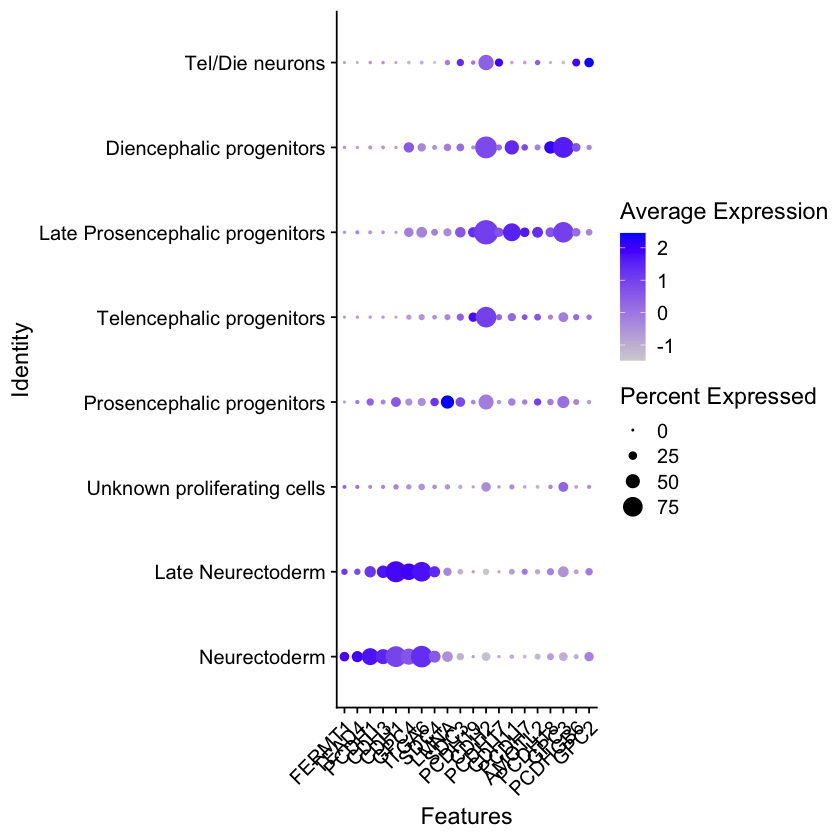

In [64]:
DotPlot(timecourse, features = unique(top5_mechano$gene), group.by = "class3") + RotatedAxis()


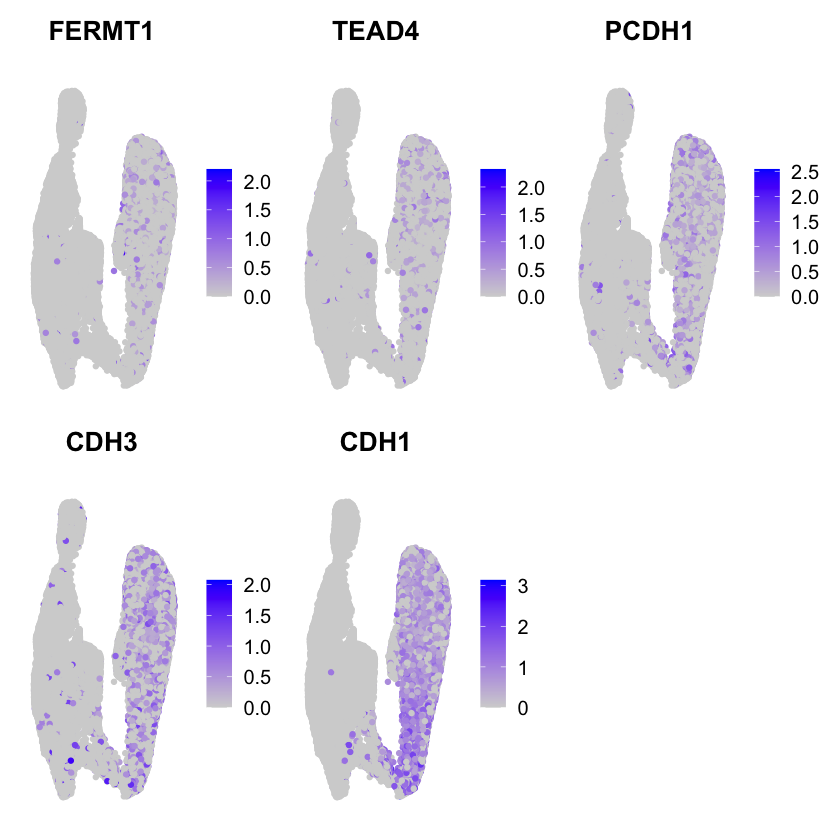

In [66]:
top5_genes <- mechano_tables[["Neurectoderm"]] %>% head(5) %>% pull(gene)

FeaturePlot(timecourse, features = top5_genes, reduction = "umap", pt.size = 1, ncol = 3) & NoAxes()


In [61]:
all_genes <- do.call(rbind, lapply(names(mechano_tables), function(ct) {
  mechano_tables[[ct]] %>% mutate(cell_type = ct)
}))

# Genes that appear as "markers" in many cell types are likely broadly expressed
gene_counts <- all_genes %>% count(gene) %>% arrange(desc(n))
gene_counts


gene,n
<chr>,<int>
CDH2,4
ITGAE,4
LATS1,4
MOB1B,4
SDC2,4
DSC2,3
FERMT2,3
GPC3,3
MOB1A,3


### Pathway / Go Analysis